In [7]:
import torch

# Load the model state dict
state_dict = torch.load("/home/jovyan/dnalm/runs/NATURE_GENA_base_linear_CRF_10k_shuffle_starts_24_classes_old_dataset_minja_test_fixed_shuffling_long/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen__len4096_maxnsegm__msz__bptt_lr5e-05_AdamW_constant_with_warmup_wd1e-04_p10000_bs_it500000/run_1/model_best/pytorch_model.bin")  # replace with your actual path

# List of tensor names or substrings to exclude
exclude_names = [
    "bert.embeddings.position_ids"
]

global_min = float('inf')
global_max = float('-inf')
min_tensor_name = ""
max_tensor_name = ""

def should_exclude(name):
    return any(excl in name for excl in exclude_names)

for name, tensor in state_dict.items():
    if isinstance(tensor, torch.Tensor) and not should_exclude(name):
        # Move to CPU if needed
        if tensor.device.type != 'cpu':
            tensor = tensor.cpu()

        t_min = tensor.min().item()
        t_max = tensor.max().item()

        if t_min < global_min:
            global_min = t_min
            min_tensor_name = name

        if t_max > global_max:
            global_max = t_max
            max_tensor_name = name

print(f"Global minimum value: {global_min} (in tensor '{min_tensor_name}')")
print(f"Global maximum value: {global_max} (in tensor '{max_tensor_name}')")


Global minimum value: -12.412406921386719 (in tensor 'A')
Global maximum value: 3.3412089347839355 (in tensor 'A')


In [1]:
import torch

In [2]:
checkpoint = torch.load('/home/jovyan/dnalm/runs/test_long_clip_grad_norm/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen__len4096_maxnsegm__msz__bptt_lr5e-05_AdamW_constant_with_warmup_wd0.0_p10000_bs_it500000/run_1/model_best/pytorch_model.bin')

In [3]:
print(checkpoint['A'].shape)

torch.Size([24, 24])


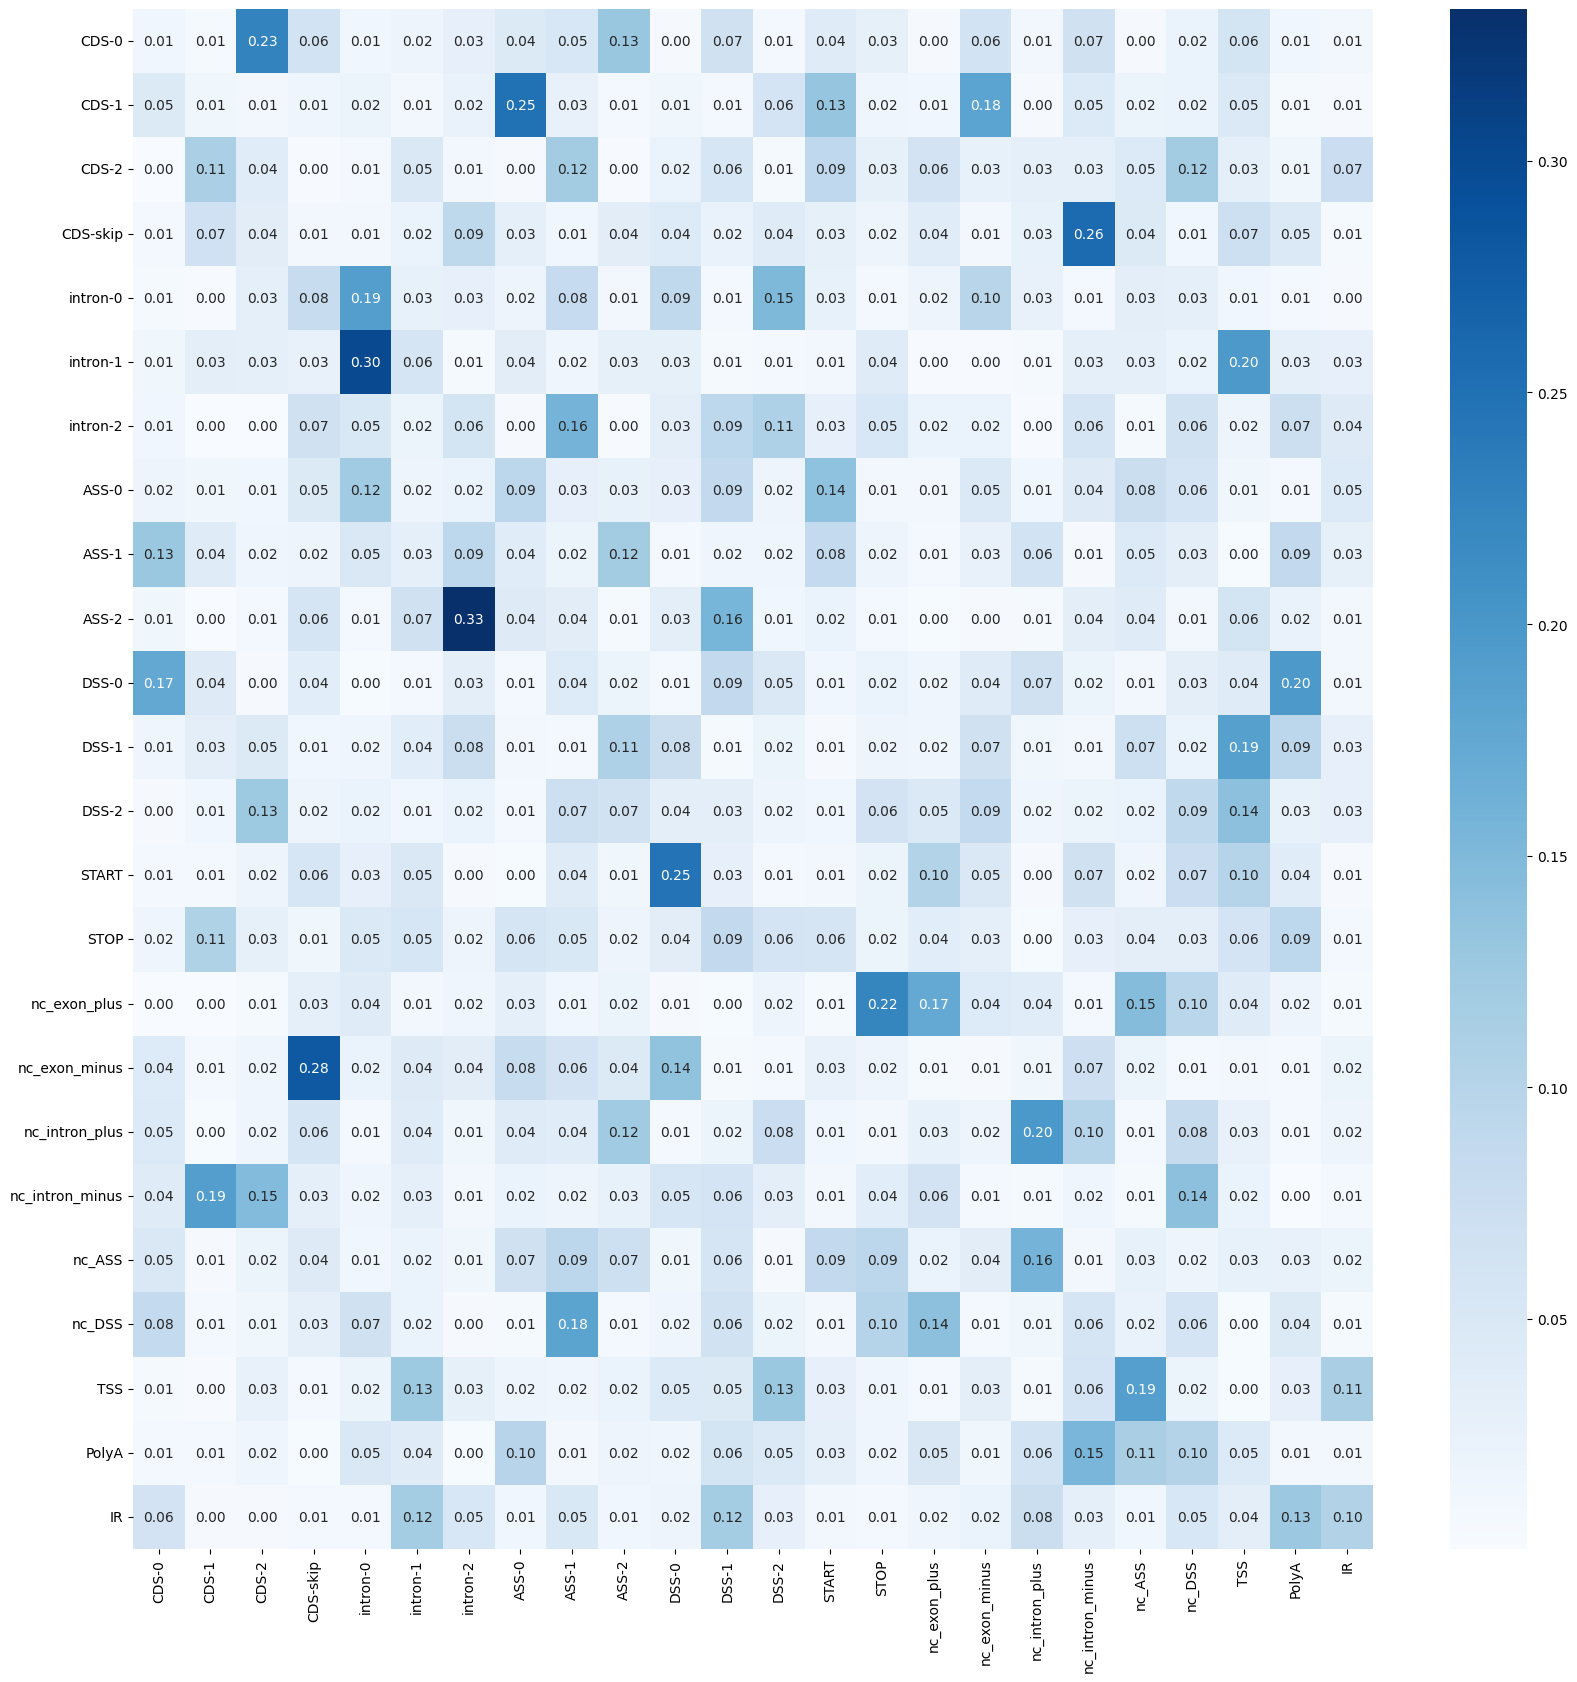

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F


label_dict = {0: 'CDS-0', 1:'CDS-1', 2:'CDS-2', 3:'CDS-skip', 4:'intron-0', 5:'intron-1', 6:'intron-2', 7:'ASS-0', 8:'ASS-1', 9:'ASS-2', 10:'DSS-0', 11:'DSS-1', 12:'DSS-2', 13:'START', 14:'STOP', 15:'nc_exon_plus', 16:'nc_exon_minus', 17:'nc_intron_plus', 18:'nc_intron_minus', 19:'nc_ASS', 20:'nc_DSS', 21:'TSS' , 22:'PolyA', 23:'IR'}
plt.figure(figsize=(20, 20))
# sns.heatmap(model.A.cpu().detach().numpy(), annot=True, fmt='.2f', cmap='Blues', xticklabels=list(label_dict.values()), yticklabels=list(label_dict.values()))
sns.heatmap(torch.nn.functional.softmax(checkpoint['A'].cpu().detach(), dim=-1).numpy(), annot=True, fmt='.2f', cmap='Blues', xticklabels=list(label_dict.values()), yticklabels=list(label_dict.values()))
# sns.heatmap(checkpoint['A'].cpu().detach().numpy(), annot=True, fmt='.2f', cmap='Blues', xticklabels=list(label_dict.values()), yticklabels=list(label_dict.values()))
plt.savefig('transitions.png')
plt.show()

# Test predictions

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
import os
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F

os.chdir('/home/jovyan/dnalm/')
from transformers import AutoTokenizer, AutoConfig
tokenizer = AutoTokenizer.from_pretrained('./data/tokenizers/t2t_1000h_multi_32k/')
from src.gena_lm.modeling_bert import BertForLetterLevelTokenClassification
model_cfg = AutoConfig.from_pretrained('./data/configs/L12-H768-A12-V32k-preln-lastln.json') # here it soulbe config for backbone model, don't change it, you can change only path to it
model_cls = BertForLetterLevelTokenClassification
model = model_cls(config=model_cfg)

rmt_config = {
    'num_mem_tokens': 10,
    'max_n_segments': 100000,
    'input_size': 512,
    'bptt_depth': -1,
    'unet_sub_model_input_size': 8192,
    'sum_loss': True,
    'tokenizer': tokenizer
}

from src.gena_lm.modeling_rmt import RMTEncoderForLetterLevelTokenClassificationLinearSegmentedRepeaterCRFfast
rmt_cls = RMTEncoderForLetterLevelTokenClassificationLinearSegmentedRepeaterCRFfast
model = rmt_cls(model, **rmt_config)
# load pre-trained weights
ckpt = torch.load(str('/home/jovyan/dnalm/runs/NATURE_GENA_RMT_4k_NUCL_BPE_ONLY_backbone_trainable_shuffle_starts_24_classes_fast_CRF_complete_random_start_minja_test/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len4098_maxnsegm_10000_msz_10_bptt-1_lr1e-04_AdamW_constant_with_warmup_wd0.0_p10000_bs_it500000/run_1/model_best/pytorch_model.bin'))
missing_k, unexpected_k = model.load_state_dict(ckpt, strict=False)
print(f'missing: {missing_k}') # if no missing tensors - that is correct, otherwise - no!
print(f'unexpected_k: {unexpected_k}') # if no missing tensors - that is correct, otherwise - no!
model_val = model.eval().to('cuda')
# model_val.half()

print('Loaded')

/home/jovyan/dnalm/my_saved_conda_envs/gena/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


missing: []
unexpected_k: []
Loaded


In [ ]:
# def prepare_sequence(sequence, tokenizer):
#     model_input = dict()
#     input_features = tokenizer([sequence], return_tensors='np')
    
# #    print(input_features['input_ids'].shape)
    
#     model_input['input_ids'] = input_features['input_ids']
#     model_input['token_type_ids'] = input_features['token_type_ids']
#     model_input['attention_mask'] = input_features['attention_mask']
#     model_input['labels'] = np.random.randint(0, 5, (1, model_input['input_ids'].shape[1], 5)) # change it in future
#     # model_input['labels_ohe'] = torch.randint(0, 5, (model_input['input_ids'].shape[0], 5)) # change it in future
#     pos_weight = torch.tensor([1.0]*5)
#     bs, seq_len = model_input['input_ids'].shape
#     model_input['pos_weight'] = pos_weight.repeat(bs, seq_len, 1)
#     model_input['labels_mask'] = (input_features['input_ids'] > 5).astype(int)
    
#     token_repeater_numbers = []
#     meaningful_tokens_only = model_input['input_ids'][model_input['input_ids'] > 5]
#     for t in meaningful_tokens_only:
#         atcg_seq_token = tokenizer.convert_ids_to_tokens(int(t))
#         token_repeater_numbers.append(len(atcg_seq_token))
    
#     token_repeater = []
#     for n, i in enumerate(token_repeater_numbers):
#         # print(i)
#         for j in range(i):
#             token_repeater.append(n)
    
#     letter_level_tokens = []
#     for letter in sequence:
#         letter_level_tokens.append(tokenizer.convert_tokens_to_ids(letter))
        
#     # if len(letter_level_tokens) < max_length:
#     #     letter_level_tokens += [-100] * (max_length - len(letter_level_tokens))
#     #     token_repeater = token_repeater + [-100] * (max_length - len(token_repeater))

#     model_input['letter_level_attention_mask'] = np.expand_dims(np.ones(len(letter_level_tokens)).astype(int), axis=0) # it's okay because we will truncate paddings with mask
#     model_input['letter_level_token_types_ids'] = np.expand_dims(np.zeros(len(letter_level_tokens)).astype(int), axis=0)
#     model_input['letter_level_tokens'] = np.expand_dims(np.array(letter_level_tokens), axis=0)
#     model_input['letter_level_labels'] = np.array([[0] * len(letter_level_tokens)]) # np.random.randint(0, 5, (1, len(letter_level_tokens), 5)) # change it in future
#     model_input['letter_level_labels_mask'] = model_input['letter_level_tokens'] != -100 #  model_input['letter_level_labels'] != -100
#     model_input['embedding_repeater'] = np.expand_dims(np.array(token_repeater), axis=0)
    
#     for k, v in model_input.items():
#         model_input[k] = torch.tensor(v).to('cuda')
#         # print(k, v.shape)
    
#     return model_input

In [3]:
def prepare_sequence(sequence, tokenizer):
    model_input = dict()
    # input_features = tokenizer([sequence], return_tensors='np')
    
#    print(input_features['input_ids'].shape)
    letter_level_tokens = []
    for letter in sequence:
        letter_level_tokens.append(tokenizer.convert_tokens_to_ids(letter))

    model_input['input_ids'] = np.expand_dims(np.array([1] + letter_level_tokens + [2]), axis=0)
    model_input['token_type_ids'] = np.expand_dims(np.zeros(model_input['input_ids'].shape[1]).astype(int), axis=0)
    model_input['attention_mask'] = np.expand_dims(np.ones(model_input['input_ids'].shape[1]).astype(int), axis=0)
    model_input['labels'] = np.random.randint(0, 5, (1, model_input['input_ids'].shape[1], 5)) # change it in future
    # model_input['labels_ohe'] = torch.randint(0, 5, (model_input['input_ids'].shape[0], 5)) # change it in future
    pos_weight = torch.tensor([1.0]*5)
    bs, seq_len = model_input['input_ids'].shape
    model_input['pos_weight'] = pos_weight.repeat(bs, seq_len, 1)
    model_input['labels_mask'] = (model_input['input_ids'] > 5).astype(int)
    
    token_repeater_numbers = []
    meaningful_tokens_only = model_input['input_ids'][model_input['input_ids'] > 5]
    for t in meaningful_tokens_only:
        atcg_seq_token = tokenizer.convert_ids_to_tokens(int(t))
        token_repeater_numbers.append(len(atcg_seq_token))
    
    token_repeater = []
    for n, i in enumerate(token_repeater_numbers):
        # print(i)
        for j in range(i):
            token_repeater.append(n)
        
    # if len(letter_level_tokens) < max_length:
    #     letter_level_tokens += [-100] * (max_length - len(letter_level_tokens))
    #     token_repeater = token_repeater + [-100] * (max_length - len(token_repeater))

    model_input['letter_level_attention_mask'] = np.expand_dims(np.ones(len(letter_level_tokens)).astype(int), axis=0) # it's okay because we will truncate paddings with mask
    model_input['letter_level_token_types_ids'] = np.expand_dims(np.zeros(len(letter_level_tokens)).astype(int), axis=0)
    model_input['letter_level_tokens'] = np.expand_dims(np.array(letter_level_tokens), axis=0)
    model_input['letter_level_labels'] = np.array([[0] * len(letter_level_tokens)]) # np.random.randint(0, 5, (1, len(letter_level_tokens), 5)) # change it in future
    model_input['letter_level_labels_mask'] = model_input['letter_level_tokens'] != -100 #  model_input['letter_level_labels'] != -100
    model_input['embedding_repeater'] = np.expand_dims(np.array(token_repeater), axis=0)
    
    for k, v in model_input.items():
        model_input[k] = torch.tensor(v).to('cuda')
        # print(k, v.shape)
    
    return model_input

In [5]:
file_path = './downstream_tasks/annotation/notebook_tests/NC_060944.1_limit_10Mb_transcript_list.txt'

selected_transcripts = []
with open(file_path, 'r') as file:
    for line in file:
        cleaned_line = line.strip()  # Removes leading/trailing whitespace including \n
        selected_transcripts.append(cleaned_line)

In [42]:
dataset_file[f'transcript_{transcript_idx}'].attrs.keys()

<KeysViewHDF5 ['ID', 'Parent', 'genome', 'seq', 'strand', 'type']>

In [43]:
dataset_file[f'transcript_{transcript_idx}'].attrs['ID']

'rna-XR_007089328.1'

In [4]:
import pickle

# Replace 'your_file.pkl' with your actual pickle file path
file_path = './downstream_tasks/annotation/notebook_tests/transcripts_test.pickle'

with open(file_path, 'rb') as file:
    transcripts_dict = pickle.load(file)

In [11]:
len(transcripts_dict.keys())

123

In [12]:
transcripts_dict.keys()

dict_keys(['rna-XR_007089328.1', 'rna-XM_047446921.1', 'rna-XR_007089329.1', 'rna-NM_153325.4', 'rna-NM_001412225.1', 'rna-NM_139074.4', 'rna-NM_001037732.3', 'rna-NM_080831.4', 'rna-NM_207469.3', 'rna-NM_153269.3', 'rna-NM_033089.7', 'rna-NR_109990.1', 'rna-NM_006943.4', 'rna-XM_047446958.1', 'rna-NM_144628.4', 'rna-NM_004609.4', 'rna-NM_080725.3', 'rna-XR_007089331.1', 'rna-NM_033129.4', 'rna-NM_015985.4', 'rna-XR_007089332.1', 'rna-XR_007089333.1', 'rna-NR_136535.1', 'rna-XR_007089335.1', 'rna-XR_007089334.1', 'rna-NM_001394958.1', 'rna-NR_037661.1', 'rna-NM_080489.5', 'rna-XR_007089336.1', 'rna-NR_040047.1', 'rna-NM_000801.5', 'rna-XR_007089337.1', 'rna-XR_007089345.1', 'rna-XR_007089346.1', 'rna-XR_007089343.1', 'rna-NM_006065.5', 'rna-NM_018556.4', 'rna-NR_110090.1', 'rna-XR_007089349.1', 'rna-XR_007089356.1', 'rna-NR_186373.1', 'rna-NR_134520.1', 'rna-NM_080836.4', 'rna-XR_007089359.1', 'rna-XR_007089360.1', 'rna-NR_161305.1', 'rna-XR_007089361.1', 'rna-XR_007089362.1', 'rna-NM_

In [6]:
import h5py
from tqdm import tqdm
import math
dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/decoding_human_mane_transcripts/gena_decoder_human_val_intergenic_2k_mane_transcripts_only.h5', "r")

exist_in_dataset = []

all_preds, all_targets = [], []
for transcript in tqdm(transcripts_dict.values()):

    num_segments = math.ceil(len(transcript) / 4096)
    # print(num_segments)
    for i in range(num_segments):
        dataset_seq_atcg = transcript[i*4096:(i+1)*4096]
        dataset_labels = np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[i*10_000:(i+1)*10_000]

        if i == 0:
            # print(len(exist_in_dataset))
            assert np.all(dataset_labels[:2000] == 23)
    
        with torch.no_grad():
            # fully_prepared_sequence = prepare_sequence(dataset_seq_atcg, tokenizer)
            gene_pred = model(**prepare_sequence(dataset_seq_atcg, tokenizer))
        gene_pred_processed = gene_pred['logits'].detach().cpu()
    
        all_preds.append(gene_pred_processed)
        all_targets.append(torch.tensor(dataset_labels))

  0%|          | 0/123 [00:00<?, ?it/s]/tmp/ipykernel_1171236/1756355683.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_input[k] = torch.tensor(v).to('cuda')
/home/jovyan/dnalm/my_saved_conda_envs/gena/lib/python3.9/site-packages/transformers/modeling_utils.py:1101: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
  0%|          | 0/123 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [46]:
import h5py
from tqdm import tqdm
import math
dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/decoding_human_mane_transcripts/gena_decoder_human_val_intergenic_2k_mane_transcripts_only.h5', "r")

exist_in_dataset = []

strands = []

slicer = 4096

all_preds, all_targets = [], []
# for transcript_idx in tqdm(range(len(dataset_file))):
for transcript_idx in tqdm(range(1000)):

    # print(np.array(dataset_file[f'transcript_{transcript_idx}']["coordinates"]))
    # if dataset_file[f'transcript_{transcript_idx}'].attrs['ID'] in selected_transcripts:
    #     exist_in_dataset.append(dataset_file[f'transcript_{transcript_idx}'].attrs['ID'])
    # print(len(np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])))
    strands.append(dataset_file[f'transcript_{transcript_idx}'].attrs['strand'])
    num_segments = math.ceil(len(np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])) / slicer)
    # print(num_segments)
    for i in range(1):
        i = np.random.randint(0, num_segments)
        # i = 1 if num_segments > 1 else 0
        # if i == 0:
        #     print('AAA')
        dataset_seq_atcg = tokenizer.decode(np.array(dataset_file[f'transcript_{transcript_idx}']["token_atcg"])[i*slicer:(i+1)*slicer])
        dataset_labels = np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[i*slicer:(i+1)*slicer]

        # if i == 0:
        #     # print(len(exist_in_dataset))
        #     assert np.all(dataset_labels[:2000] == 23)
    
        with torch.no_grad():
            # fully_prepared_sequence = prepare_sequence(dataset_seq_atcg, tokenizer)
            gene_pred = model(**prepare_sequence(dataset_seq_atcg, tokenizer))
        gene_pred_processed = gene_pred['logits'].detach().cpu()
    
        all_preds.append(gene_pred_processed)
        all_targets.append(torch.tensor(dataset_labels))

  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_1171236/1756355683.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_input[k] = torch.tensor(v).to('cuda')
/home/jovyan/dnalm/my_saved_conda_envs/gena/lib/python3.9/site-packages/transformers/modeling_utils.py:1101: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|██████████| 1000/1000 [11:08<00:00,  1.50it/s]


In [13]:
np.unique(strands, return_counts=True)

(array(['+', '-'], dtype='<U1'), array([506, 494]))

In [45]:
import pickle

# Replace 'your_file.pkl' with your actual pickle file path
file_path = './downstream_tasks/annotation/notebook_tests/10k.pickle'

with open(file_path, 'rb') as file:
    pickle_file = pickle.load(file)

In [62]:
len(exist_in_dataset)

123

In [31]:
np.all(pickle_file['embedding_repeater'].squeeze().cpu().numpy() == fully_prepared_sequence['embedding_repeater'].squeeze().cpu().numpy())

ValueError: operands could not be broadcast together with shapes (10000,) (5070,) 

In [190]:
np.all(np.load('./downstream_tasks/annotation/notebook_tests/bpe_10k.npy').squeeze() == fully_prepared_sequence['input_ids'].squeeze().cpu().numpy())

True

In [188]:
np.load('./downstream_tasks/annotation/notebook_tests/bpe_10k.npy').squeeze()[:10]

array([    1,   923,   216,  9523,   598,   205,   112,  1616,   294,
       13820])

In [189]:
fully_prepared_sequence['input_ids'].squeeze()[:10]

tensor([    1,   923,   216,  9523,   598,   205,   112,  1616,   294, 13820],
       device='cuda:0')

In [187]:
np.sum(np.load('./downstream_tasks/annotation/notebook_tests/bpe_10k.npy').squeeze() == fully_prepared_sequence['input_ids'].squeeze())

0

In [185]:
len(fully_prepared_sequence['input_ids'].squeeze())

1508

In [186]:
len(np.load('./downstream_tasks/annotation/notebook_tests/bpe_10k.npy').squeeze())

1508

In [168]:
output_path = './downstream_tasks/annotation/notebook_tests/selected_transcripts.txt'

with open(output_path, 'w') as file:
    for line in exist_in_dataset:
        file.write(line + '\n')  # Add newline character back for each line

In [61]:
len(selected_transcripts)

170

In [25]:
torch.cat(all_preds, dim=-1).shape

torch.Size([1, 3580550])

In [26]:
torch.cat(all_targets, dim=-1).shape

torch.Size([3580550])

In [33]:
def find_segments_ones(array):
    ones_idx = np.where(array == 1)[0]
    if len(ones_idx) == 0:
        return []

    split_idx = np.where(np.diff(ones_idx) > 1)[0] + 1

    split_ones_idx = np.split(ones_idx, split_idx)
    segments = [(segment[0], segment[-1] + 1) for segment in split_ones_idx]

    return segments

def exon_level(y_labels, p_labels, metrics):     
    """
    Update metrics with chosen threshold
    """
    y_labels_segments = find_segments_ones(np.where(y_labels >= 0.5, 1, 0))    
    p_labels_segments = find_segments_ones(np.where(p_labels >= 0.5, 1, 0))


    y_exons_set = set(sorted(y_labels_segments))
    p_exons_set = set(sorted(p_labels_segments))

    assert metrics[f'TP'] == 0
    assert metrics[f'FP'] == 0
    assert metrics[f'FN'] == 0
    
    metrics[f'TP'] += len(y_exons_set & p_exons_set)
    metrics[f'FP'] += len(p_exons_set - y_exons_set)
    metrics[f'FN'] += len(y_exons_set - p_exons_set)

In [47]:
all_pred = torch.cat(all_preds, dim=-1).squeeze()
all_y = torch.cat(all_targets, dim=-1)

In [48]:
np.unique(all_y, return_counts=True)

(array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23]),
 array([ 40333,  40445,  40328, 354827, 241562, 421881,    111,     74,
           178,     99,     88,    173,     69,     69, 207927, 156588,
        628392, 602299,    285,    267,    217,    239, 852509]))

In [52]:
first_pred = np.load('./downstream_tasks/annotation/notebook_tests/first_preds.npy')
decreaser = 3
np.all(all_pred[:].numpy() == first_pred[:])

True

In [37]:
all_pred.sum()

tensor(303176)

In [38]:
np.sum(~(all_pred.numpy() == first_pred))

142

In [59]:
all_pred[10_000-7:10_000+7]

tensor([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23])

In [60]:
first_pred[10_000-7:10_000+7]

array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23])

In [76]:
torch.sum(all_pred == 21)

tensor(481)

In [49]:
metrics = {}

assert -100 not in all_pred
assert -100 not in all_y

label_dict = {0: 'CDS-0', 1:'CDS-1', 2:'CDS-2', 3:'CDS-skip', 4:'intron-0', 5:'intron-1', 6:'intron-2', 7:'ASS-0', 8:'ASS-1', 9:'ASS-2', 10:'DSS-0', 11:'DSS-1', 12:'DSS-2', 13:'START', 14:'STOP', 15:'nc_exon_plus', 16:'nc_exon_minus', 17:'nc_intron_plus', 18:'nc_intron_minus', 19:'nc_ASS', 20:'nc_DSS', 21:'TSS' , 22:'PolyA', 23:'IR'}

# metrics['pr_auc_mean'] = 0
metrics['f1_mean'] = 0
# metrics['val_counter'] = val_counter
# val_counter += 1
for label in range(24):
    # print(y_rmt)
    y_label = (all_y == label).type(torch.int32)
    p_label = (all_pred == label).type(torch.int32)

    # print(y_label, p_label)
    # assert False
    
    # if not np.isnan(p_label).any():
    #     pr_auc = average_precision_score(y_label, p_label, pos_label=1)
    # else:
    #     pr_auc = np.nan
    # # to be compatible with sklearn 1.1+
    # metrics[f'pr_auc_{label_dict[label]}'] = pr_auc if not np.isnan(pr_auc) else 0.0

    # metrics['pr_auc_mean'] += metrics[f'pr_auc_{label_dict[label]}']

    exon_level_data = {}

    exon_level_data[f'TP'] = 0
    exon_level_data[f'FP'] = 0
    exon_level_data[f'FN'] = 0

    exon_level(y_label, p_label, exon_level_data)

    print(f'TP: {label_dict[label]}', exon_level_data[f'TP'])

    if exon_level_data[f'TP'] == 0 and exon_level_data[f'FN'] == 0:
        recall = 0
    else:
        recall = exon_level_data[f'TP'] / (exon_level_data[f'TP'] + exon_level_data[f'FN'])
        
    if exon_level_data[f'TP'] == 0 and exon_level_data[f'FP'] == 0:
        precision = 0
    else:
        precision = exon_level_data[f'TP'] / (exon_level_data[f'TP'] + exon_level_data[f'FP'])    

    if precision == 0 and recall == 0:
        f1 = 0
    else:
        f1 = 2 * recall * precision / (recall + precision) 

    metrics[f'f1_{label_dict[label]}_level'] = f1
    metrics['f1_mean'] += metrics[f'f1_{label_dict[label]}_level']
    metrics[f'precision_{label_dict[label]}_level'] = precision
    metrics[f'recall_{label_dict[label]}_level'] = recall

# metrics['pr_auc_mean'] /= 24
metrics['f1_mean'] /= 24

TP: CDS-0 17836
TP: CDS-1 17892
TP: CDS-2 17875
TP: CDS-skip 0
TP: intron-0 22
TP: intron-1 10
TP: intron-2 27
TP: ASS-0 26
TP: ASS-1 10
TP: ASS-2 36
TP: DSS-0 30
TP: DSS-1 10
TP: DSS-2 35
TP: START 19
TP: STOP 22
TP: nc_exon_plus 44
TP: nc_exon_minus 34
TP: nc_intron_plus 24
TP: nc_intron_minus 10
TP: nc_ASS 38
TP: nc_DSS 52
TP: TSS 82
TP: PolyA 87
TP: IR 128


In [50]:
metrics

{'f1_mean': 0.24317323370289534,
 'f1_CDS-0_level': 0.556896417141519,
 'precision_CDS-0_level': 0.7518758957929348,
 'recall_CDS-0_level': 0.44221853073165895,
 'f1_CDS-1_level': 0.5570101022679513,
 'precision_CDS-1_level': 0.751827884696193,
 'recall_CDS-1_level': 0.44237853875633576,
 'f1_CDS-2_level': 0.5582448469706432,
 'precision_CDS-2_level': 0.7538059292371273,
 'recall_CDS-2_level': 0.44325141964440695,
 'f1_CDS-skip_level': 0,
 'precision_CDS-skip_level': 0,
 'recall_CDS-skip_level': 0,
 'f1_intron-0_level': 0.16603773584905657,
 'precision_intron-0_level': 0.2682926829268293,
 'recall_intron-0_level': 0.12021857923497267,
 'f1_intron-1_level': 0.12578616352201258,
 'precision_intron-1_level': 0.5555555555555556,
 'recall_intron-1_level': 0.07092198581560284,
 'f1_intron-2_level': 0.15561959654178675,
 'precision_intron-2_level': 0.32142857142857145,
 'recall_intron-2_level': 0.10266159695817491,
 'f1_ASS-0_level': 0.29213483146067415,
 'precision_ASS-0_level': 0.3880597014

# Test dataset

In [14]:
train_dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/decoding_human_mane_transcripts/gena_decoder_human_train_intergenic_2k_mane_transcripts_only.h5', "r")

In [32]:
transcript_idx = 100
bias = 200

transcript_stats = dict()

transcript_stats[train_dataset_file[f'transcript_{transcript_idx}'].attrs['ID'] + '|strand'] = train_dataset_file[f'transcript_{transcript_idx}'].attrs['strand']
transcript_stats[train_dataset_file[f'transcript_{transcript_idx+bias}'].attrs['ID'] + '|strand'] = train_dataset_file[f'transcript_{transcript_idx+bias}'].attrs['strand']
transcript_stats

{'rna-NM_001242672.3|strand': '-', 'rna-NM_006474.5|strand': '+'}

In [29]:
def write_igv_bed(p_labels, start_seq, label, name,  file_path, chrom):
    with open(f"{file_path}/{label}_{name}.bed", "a") as text:
        for i, (start, end) in enumerate(p_labels):
            text.write(f"{chrom}\t{start_seq + start}\t{start_seq + end}\n")

def find_segments_ones(array):
    
    ones_idx = np.where(array == 1)[0]
    if ones_idx.size == 0:
        return []

    split_idx = np.where(np.diff(ones_idx) > 1)[0] + 1
    split_ones_idx = np.split(ones_idx, split_idx)

    return [(segment[0], segment[-1] + 1) for segment in split_ones_idx]

In [34]:
np.unique(train_dataset_file[f'transcript_{transcript_idx+200}']['labels'])

array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 21, 22,
       23])

In [37]:
train_dataset_file[f'transcript_{transcript_idx+bias}']['labels'][1995:2005]

array([23, 23, 23, 23, 23, 21, 15, 15, 15, 15])

In [44]:
import numpy as np
from typing import Sequence

def fill_segments(arr: np.ndarray, values: Sequence[int]) -> np.ndarray:
    """
    Same as before, but for a run touching the left or right end of the array,
    we only fill from the *existing* neighbor and leave the other side unchanged.

    Parameters
    ----------
    arr : np.ndarray
        One-dimensional array of ints.
    values : Sequence[int]
        Values whose runs we want to process, in order.

    Returns
    -------
    np.ndarray
        A new array (same shape) with each specified value’s runs “filled”
        from their on-array neighbors, leaving only the center element of each
        run at v, and *not* falling back to the opposite side if one side
        is out of bounds.
    """
    out = np.asarray(arr).copy()
    n = out.size

    for v in values:
        mask = (out == v)
        # pad so we can detect runs at the very ends
        padded = np.r_[False, mask, False]
        diff = np.diff(padded.astype(int))
        starts = np.where(diff ==  1)[0]
        ends   = np.where(diff == -1)[0] - 1

        for start, end in zip(starts, ends):
            c = (start + end) // 2

            # only use left neighbor if it exists
            left_val = out[start-1] if start > 0 else None
            # only use right neighbor if it exists
            right_val = out[end+1] if end+1 < n else None

            # fill left half of the run
            if left_val is not None and start < c:
                out[start:c] = left_val
            # fill right half of the run
            if right_val is not None and c < end:
                out[c+1:end+1] = right_val
            # leave out[c] == v

    return out


In [49]:
import numpy as np

arr = np.array([1, 2, 2, 2, 3, 2, 4, 4, 8])

filled = fill_segments(arr, [2, 4])
print(filled)


[1 1 2 3 3 2 4 8 8]
